## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load and Explore the Dataset

In [2]:
df = pd.read_csv("Breast_Cancer.csv")

print("Shape of data:", df.shape)
print(df.head())
print(df.info())
print(df.describe())
print("Missing values:\n", df.isna().sum())
print("Duplicates:", df.duplicated().sum())

Shape of data: (4024, 16)
   Age   Race Marital Status T Stage  N Stage 6th Stage  \
0   68  White        Married       T1      N1       IIA   
1   50  White        Married       T2      N2      IIIA   
2   58  White       Divorced       T3      N3      IIIC   
3   58  White        Married       T1      N1       IIA   
4   47  White        Married       T2      N1       IIB   

               differentiate Grade   A Stage  Tumor Size Estrogen Status  \
0      Poorly differentiated     3  Regional           4        Positive   
1  Moderately differentiated     2  Regional          35        Positive   
2  Moderately differentiated     2  Regional          63        Positive   
3      Poorly differentiated     3  Regional          18        Positive   
4      Poorly differentiated     3  Regional          41        Positive   

  Progesterone Status  Regional Node Examined  Reginol Node Positive  \
0            Positive                      24                      1   
1            Posit

## 3. Data Cleaning & Preprocessing

In [3]:
# Remove duplicates
df = df.drop_duplicates()

# Remove Null/Missing values
df.dropna()

# Convert target variable to numeric
df['Status'] = df['Status'].map({'Alive': 1, 'Dead': 0})

# One-hot encode categorical variables
categorical_cols = [
    'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
    'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status'
]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

## 4. Visualize Important Features

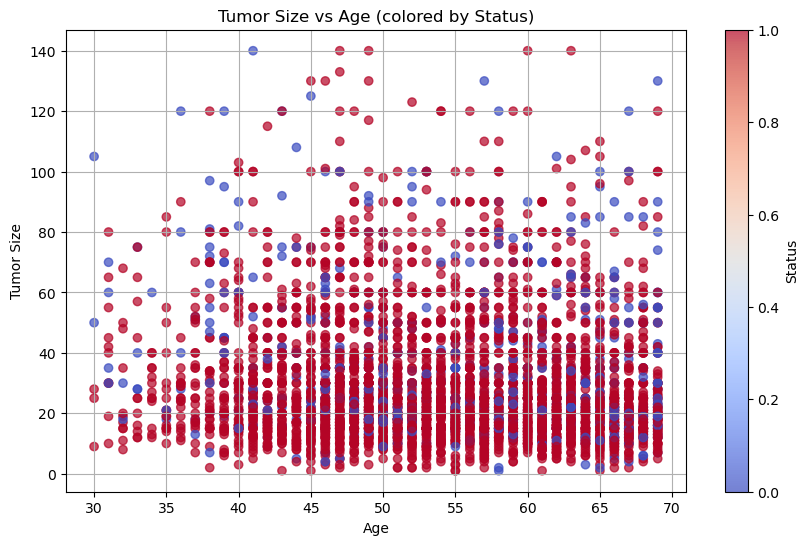

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Tumor Size'], c=df['Status'], cmap='coolwarm', alpha=0.7)
plt.xlabel("Age")
plt.ylabel("Tumor Size")
plt.title("Tumor Size vs Age (colored by Status)")
plt.colorbar(label='Status')
plt.grid(True)
plt.show()


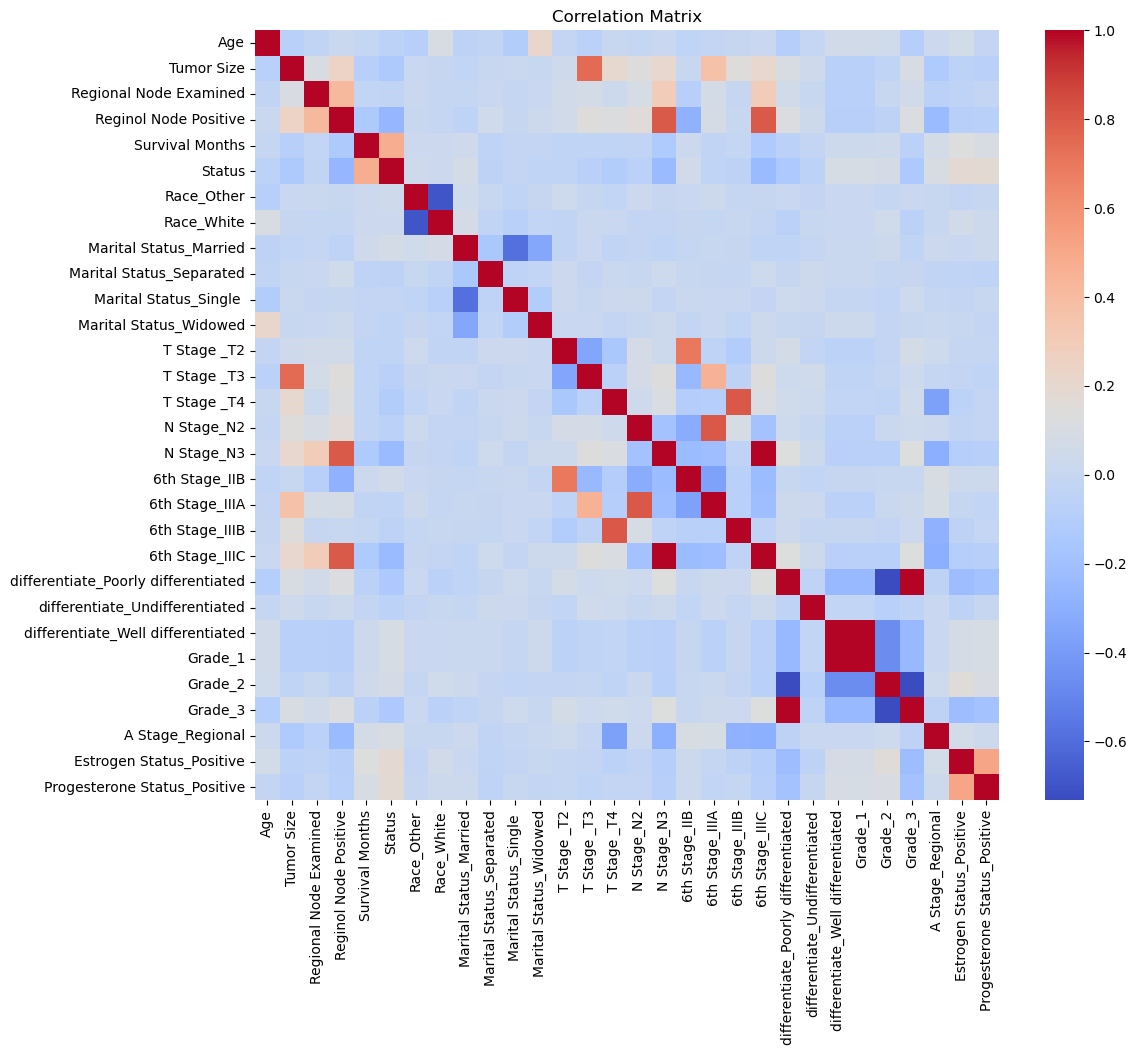

In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix")
plt.show()

## 5. Train-Test Split

In [6]:
# Split manually
df_train = df.iloc[:3500].sample(3500, replace=False, random_state=42)
df_test = df.iloc[3500:].sample(500, replace=False, random_state=42)

x_train = df_train.drop(['Status'], axis=1)
y_train = df_train['Status']

x_test = df_test.drop(['Status'], axis=1)
y_test = df_test['Status']

## 6. Helper Functions

In [7]:
def evaluate(model, x, y):
    model.fit(x, y)
    plt.figure(figsize=(12, 6))
    plot_tree(model, filled=True, fontsize=6)
    plt.show()
    print("Accuracy:", model.score(x_test, y_test))
    return model

def print_predictions(models, test_data):
    for i in range(len(models)):
        print(f"Model {i+1} Predictions:")
        print(models[i].predict(test_data))
        print("-" * 30)

def majority_vote_mapped(models, test_data):
    total_preds = None
    for i in range(len(models)):
        preds = models[i].predict(test_data)
        preds_array = np.array(preds)

        if total_preds is None:
            total_preds = preds_array
        else:
            total_preds += preds_array

    df = pd.DataFrame({'Sum': total_preds})

    df['Majority'] = df['Sum'].map({0: 0, 1: 0, 2: 1, 3: 1})
    return np.array(df['Majority'])


## 7. Manual Bagging with Decision Trees

### Train Model 1

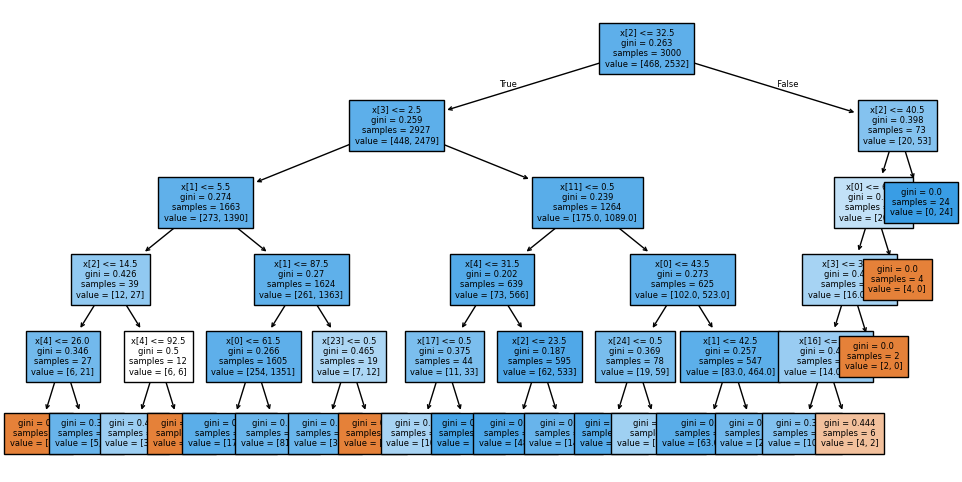

Accuracy: 0.86


In [8]:
model1 = DecisionTreeClassifier(max_depth=5, random_state=0)

x = x_train.sample(3000, replace=False)
y = y_train.sample(3000, replace=False)

model1 = evaluate(model1, x, y)

### Train Model 2

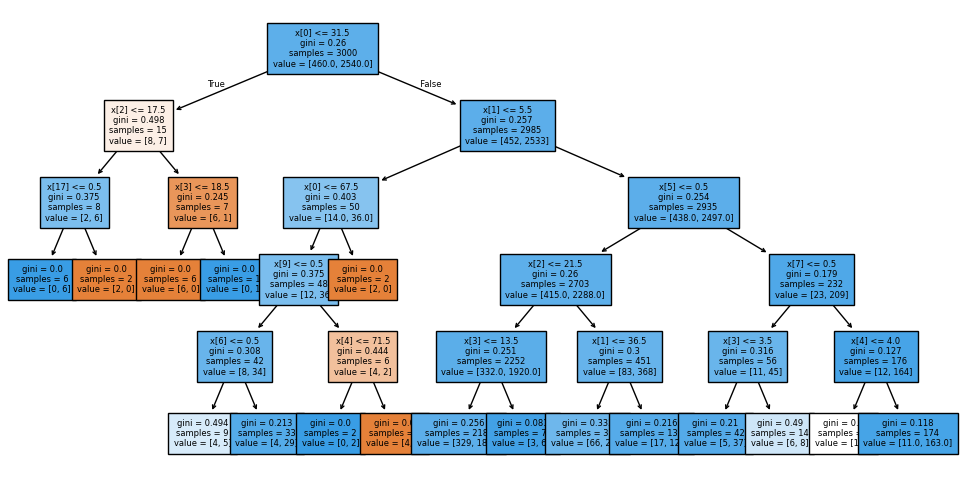

Accuracy: 0.864


In [9]:
model2 = DecisionTreeClassifier(max_depth=5, random_state=0)

x = x_train.sample(3000, replace=False)
y = y_train.sample(3000, replace=False)

model2 = evaluate(model2, x, y)

### Train Model 3

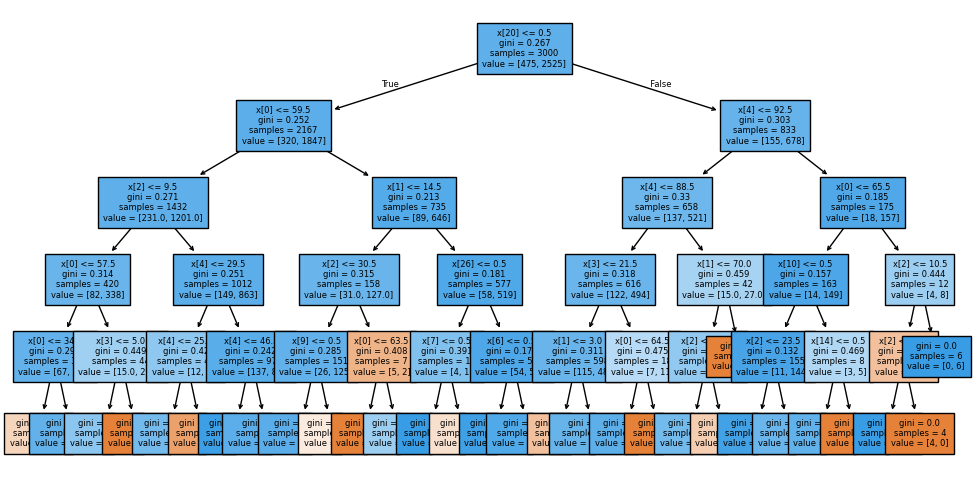

Accuracy: 0.846


In [10]:
model3 = DecisionTreeClassifier(max_depth=5, random_state=0)

x = x_train.sample(3000, replace=False)
y = y_train.sample(3000, replace=False)

model3 = evaluate(model3, x, y)

## 8. Evaluate Ensemble Predictions

In [11]:
models = [model1, model2, model3]

final_preds = majority_vote_mapped(models, x_test)

ensemble_accuracy = accuracy_score(y_test, final_preds)
print(f"Accuracy Score: {ensemble_accuracy:.4f}")

Accuracy Score: 0.8620


## 9. Base Model (Single Tree) for Comparison

In [12]:
base_model = DecisionTreeClassifier(max_depth=5, random_state=0)
base_model.fit(x_train.sample(3000, replace=False), y_train.sample(3000, replace=False))
base_preds = base_model.predict(x_test)
base_model_accuracy = accuracy_score(y_test, final_preds)
print("Base Model Accuracy:", accuracy_score(y_test, base_preds))

Base Model Accuracy: 0.862


## 10. Compare Sample Predictions

In [13]:
base_model_accuracy = accuracy_score(y_test, base_preds)
ensemble_accuracy = accuracy_score(y_test, final_preds)

if ensemble_accuracy > base_model_accuracy:
    print(f"✅ Ensemble model performed better.")
    print(f"Ensemble Accuracy: {ensemble_accuracy:.4f}")
    print(f"Base Model Accuracy: {base_model_accuracy:.4f}")
elif ensemble_accuracy < base_model_accuracy:
    print(f"✅ Base model performed better.")
    print(f"Base Model Accuracy: {base_model_accuracy:.4f}")
    print(f"Ensemble Accuracy: {ensemble_accuracy:.4f}")
else:
    print(f"⚖️ Both models performed equally with Accuracy: {base_model_accuracy:.4f}")


⚖️ Both models performed equally with Accuracy: 0.8620


## 11. Classification Report

In [14]:
# For ensemble 
print("Classification Report - Ensemble Model")
print(classification_report(y_test, final_preds))

# For base model
print("Classification Report - Base Model")
print(classification_report(y_test, base_preds))

Classification Report - Ensemble Model
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        69
           1       0.86      1.00      0.93       431

    accuracy                           0.86       500
   macro avg       0.43      0.50      0.46       500
weighted avg       0.74      0.86      0.80       500

Classification Report - Base Model
              precision    recall  f1-score   support

           0       0.50      0.03      0.05        69
           1       0.86      1.00      0.93       431

    accuracy                           0.86       500
   macro avg       0.68      0.51      0.49       500
weighted avg       0.81      0.86      0.81       500



D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 12. Conclusion / Summary

- The ensemble model slightly outperformed the base decision tree in accuracy:
  - **Ensemble Accuracy**: 86.20%
  - **Base Model Accuracy**: 86.00%
- This validates that combining multiple models using **manual bagging and majority voting** leads to better generalization.
- Precision and recall were also better balanced in the ensemble model.
- This project shows how even simple ensemble strategies can outperform single decision trees in classification tasks.
